In [ ]:
!pip install caveclient
!pip install standard_transform

In [ ]:
from os.path import join as pjoin
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from caveclient import CAVEclient
from matplotlib.colors import LogNorm
from concurrent.futures import ThreadPoolExecutor, as_completed


In [ ]:
# from google import colab
# colab.drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from caveclient import CAVEclient

# What version to materialize from CAVE (latest)
version = 1718
my_token = "4aa8631cb4aae9084799b4e0935bf648"
# Initialize caveclient and set version
client = CAVEclient('minnie65_public', auth_token=my_token)
timestamp = client.materialize.get_timestamp(version=client.materialize.version)
client.version = version
client.materialize.get_tables()

['synapses_pni_2',
 'nucleus_detection_v0',
 'vortex_manual_nodes_of_ranvier',
 'bodor_pt_target_proofread',
 'baylor_gnn_cell_type_fine_model_v2',
 'nucleus_alternative_points',
 'nucleus_functional_area_assignment',
 'coregistration_auto_phase3_fwd_apl_vess_combined_v2',
 'aibs_metamodel_mtypes_v661_v2_corrections',
 'vortex_thalamic_proofreading_status',
 'allen_column_mtypes_v2',
 'proofreading_status_and_strategy',
 'bodor_pt_cells',
 'aibs_metamodel_mtypes_v661_v2',
 'aibs_metamodel_celltypes_v661_corrections',
 'vortex_microglia_proofreading_status',
 'allen_v1_column_types_slanted_ref',
 'multi_input_spine_predictions_ssa',
 'aibs_column_nonneuronal_ref',
 'nucleus_ref_neuron_svm',
 'synapse_target_structure',
 'myelin_auto_tags_2points',
 'apl_functional_coreg_vess_fwd',
 'vortex_axon_backtrace_column',
 'cell_type_multifeature_combo',
 'vortex_compartment_targets',
 'baylor_log_reg_cell_type_coarse_v1',
 'vortex_synapse_reattachment',
 'coregistration_auto_phase3_fwd_v2',
 's

In [ ]:
# get cell info for the requested version
cell_df = client.materialize.views.aibs_cell_info().query(
    select_columns =['id','pt_root_id','broad_type','cell_type','mtype','meso_type','visual_area','pt_position'],
    materialization_version=version,
    split_positions=True,
)

if np.isin('pt_supervoxel_id', cell_df.columns):
    cell_df = cell_df.drop(columns = 'pt_supervoxel_id')

# Drop duplicates on pt_root_id, and pt_root_id=0
cell_df = cell_df.drop_duplicates(subset='pt_root_id', keep=False)

# Clean the manual cell categories for clarity
ct_mapping = {'WM-P': '6P-CT', '6P-U': '6P-IT', 'error': np.nan}
cell_df['cell_type'] = cell_df.cell_type.replace(ct_mapping)

# Add the functional data
functional_ids = client.materialize.tables.coregistration_manual_v4().query(
    materialization_version=version).id.values

cell_df['coreg'] = cell_df.id.isin(functional_ids)

# Add if cell is in the V1 Column
column_roots = client.materialize.tables.allen_v1_column_types_slanted_ref().query()['pt_root_id'].to_numpy()
cell_df['is_column'] = cell_df.pt_root_id.isin(column_roots)
cell_df.head()


,id,pt_root_id,broad_type,cell_type,mtype,meso_type,visual_area,pt_position_x,pt_position_y,pt_position_z,coreg,is_column
2,1841,864691134896214318,<NA>,<NA>,<NA>,<NA>,V1,57536,105584,19883,False,False
4,1998,864691136050815731,<NA>,<NA>,<NA>,<NA>,V1,59936,105872,20078,False,False
7,2026,864691134226817318,<NA>,<NA>,<NA>,<NA>,V1,60832,100752,19857,False,False
9,2198,864691135013273238,<NA>,<NA>,<NA>,<NA>,V1,65088,104160,20059,False,False
10,2199,864691136521572241,<NA>,<NA>,<NA>,<NA>,V1,65664,109488,19839,False,False


In [ ]:
# Add the proofreading status
prf_df = client.materialize.tables.proofreading_status_and_strategy().query(
    select_columns = ['pt_root_id','valid_id','status_dendrite','status_axon',
                      'strategy_dendrite','strategy_axon'],
    materialization_version = version
)

if np.isin('pt_supervoxel_id', prf_df.columns):
        prf_df = prf_df.drop(columns = 'pt_supervoxel_id')

# Select only proofread where the root_id==valid_id (no further proofreading after validation)
prf_df = prf_df.query("pt_root_id==valid_id")
prf_df = prf_df.drop(columns=['valid_id'])

# Merge to cell types
cell_df = (cell_df.merge(prf_df, on='pt_root_id', how='left')
           .fillna({'status_dendrite': False,
                    'status_axon': False,
                    'strategy_dendrite': 'none',
                    'strategy_axon': 'none',
                   })
           .astype({'status_dendrite': bool, 'status_axon': bool})
          )

/tmp/ipykernel_19784/638957928.py:12: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  prf_df = prf_df.query("pt_root_id==valid_id")


In [ ]:
cell_df.count()
cell_df.head(4)

,id,pt_root_id,broad_type,cell_type,mtype,meso_type,visual_area,pt_position_x,pt_position_y,pt_position_z,coreg,is_column,status_dendrite,status_axon,strategy_dendrite,strategy_axon
0,1841,864691134896214318,<NA>,<NA>,<NA>,<NA>,V1,57536,105584,19883,False,False,False,False,none,none
1,1998,864691136050815731,<NA>,<NA>,<NA>,<NA>,V1,59936,105872,20078,False,False,False,False,none,none
2,2026,864691134226817318,<NA>,<NA>,<NA>,<NA>,V1,60832,100752,19857,False,False,False,False,none,none
3,2198,864691135013273238,<NA>,<NA>,<NA>,<NA>,V1,65088,104160,20059,False,False,False,False,none,none


In [ ]:
from standard_transform import minnie_ds

X_transformed = minnie_ds.transform_vx.apply_dataframe('pt_position', cell_df)
X_transformed = np.array(X_transformed)
cell_df['pt_position_x_tform'] = X_transformed[:,0]
cell_df['pt_position_y_tform'] = X_transformed[:,1]
cell_df['pt_position_z_tform'] = X_transformed[:,2]

In [ ]:
v1_column_df = cell_df[cell_df['is_column'] == True]
v1_column_df.count()
v1_column_df.head()
# v1_column_df.cell_type.value_counts()
global_root_ids = v1_column_df['pt_root_id']
# global_root_ids = list(global_root_ids)
display(global_root_ids.count())
global_root_ids.head()

np.int64(1357)

,pt_root_id
33069,864691136723961597
33263,864691135741458324
33264,864691135303514791
33265,864691136111478712
33268,864691136011684526


In [ ]:
import numpy as np
import os

# Define the path to the numpy file
npy_path = '/content/drive/MyDrive/WenLab/scale_invariant/Functional_data_access/cal_trace_keys.npy'

if os.path.exists(npy_path):
    # Load the IDs from the numpy file
    neuron_ids_array = np.load(npy_path)

    # Ensure both are integers for accurate matching
    neuron_ids_int = neuron_ids_array
    global_ids_int = global_root_ids.to_numpy()

    # Calculate the intersection
    intersection = np.intersect1d(neuron_ids_int, global_ids_int)

    print(f"Total IDs in numpy file: {len(neuron_ids_int)}")
    print(f"Total IDs in global_root_ids: {len(global_ids_int)}")
    print(f"Number of matching IDs: {len(intersection)}")
    print(f'ration of persistent neuron:{len(intersection)/len(neuron_ids_int)}')
    print(type(intersection))
    intersection_int = intersection.astype(int)
    print(intersection_int)

    # Slice the original DataFrame using the matches
    intersection_df = v1_column_df[v1_column_df['pt_root_id'].astype(int).isin(intersection_int)].copy()
    if not intersection_df.empty:
        print("\nMatching Data Samples:")
        display(intersection_df.head())
    else:
        print("\nNo matching records found in the current DataFrame.")
else:
    print(f"Error: File not found at {npy_path}")

Total IDs in numpy file: 112
Total IDs in global_root_ids: 1357
Number of matching IDs: 71
ration of persistent neuron:0.6339285714285714
<class 'numpy.ndarray'>
[648518346349524096 648518346349532032 648518346349532032
 648518346349534080 648518346349534080 648518346349536384
 648518346349536768 648518346349536768 648518346349536896
 648518346349536896 648518346349537280 648518346349537280
 648518346349537280 648518346349537536 648518346349537536
 648518346349537536 648518346349537536 648518346349537664
 648518346349537792 648518346349537792 648518346349537792
 648518346349537792 648518346349537792 648518346349537920
 648518346349537920 648518346349537920 648518346349538048
 648518346349538048 648518346349538048 648518346349538176
 648518346349538176 648518346349538176 648518346349538304
 648518346349538304 648518346349538304 648518346349538432
 648518346349538432 648518346349538432 648518346349538432
 648518346349538688 648518346349538688 648518346349538688
 648518346349539072 648518

In [ ]:
import numpy as np

# 1. 检查数据类型
print(f"Column pt_root_id dtype: {v1_column_df['pt_root_id'].dtype}")

# 2. 尝试使用整数进行查询（不加引号）
# 在 CAVE 中，root_id 通常是 64 位整数
target_id = 648518346349532032
print(type(target_id))
target_id = np.array(target_id, dtype = np.int64)
example_df = v1_column_df[v1_column_df['pt_root_id'] == target_id]

print(f"\nUsing integer {target_id}, found rows: {len(example_df)}")
display(example_df)

Column pt_root_id dtype: Int64
<class 'int'>

Using integer 648518346349532032, found rows: 0


,id,pt_root_id,broad_type,cell_type,mtype,meso_type,visual_area,pt_position_x,pt_position_y,pt_position_z,coreg,is_column,status_dendrite,status_axon,strategy_dendrite,strategy_axon,pt_position_x_tform,pt_position_y_tform,pt_position_z_tform


In [ ]:
# 1. 使用 Python 内置的 type() 函数查看变量本身的类
print(f"Variable 'target_id' type: {type(target_id)}")
print(f"Variable 'v1_column_df' type: {type(v1_column_df)}")

# 2. 对于 NumPy 或 Pandas 对象，查看其内部存储的数据类型 (dtype)
print(f"\nPandas Series 'pt_root_id' dtype: {v1_column_df['pt_root_id'].dtype}")

# 3. 如果是 NumPy 数组
import numpy as np
arr = np.array([1, 2, 3], dtype=np.int64)
print(f"NumPy array type: {type(arr)}")
print(f"NumPy array element dtype: {arr.dtype}")

In [ ]:
import numpy as np

# Let's inspect the ID values to see if they are even in the same range/format
neuron_ids_raw = np.load('/content/drive/MyDrive/WenLab/scale_invariant/Functional_data_access/cal_trace_keys.npy')
column_ids_raw = global_root_ids.to_numpy()

print("Sample IDs from Numpy file (raw):")
print(neuron_ids_raw[:5])
print("\nSample IDs from V1 Column (raw):")
print(column_ids_raw[:5])

print("\nMax value Numpy:", neuron_ids_raw.max())
print("Max value Column:", column_ids_raw.max())

# Check if any ID from numpy file is contained in the broad cell_df (not just column)
intersection_broad = np.intersect1d(neuron_ids_raw.astype(int), cell_df['pt_root_id'].to_numpy().astype(int))
print(f"\nIntersection with FULL cell_df: {len(intersection_broad)}")

Sample IDs from Numpy file (raw):
[648518346349539895 648518346349537860 648518346349538440
 648518346349538527 648518346349538209]

Sample IDs from V1 Column (raw):
[864691136723961597 864691135741458324 864691135303514791
 864691136111478712 864691136011684526]

Max value Numpy: 648518346349540053
Max value Column: 864691137199860033

Intersection with FULL cell_df: 0


In [ ]:
v1_column_df.value_counts(['cell_type']).sort_index()

,count
cell_type,
23P,349
4P,268
5P-ET,40
5P-IT,140
5P-NP,11
6P-CT,164
6P-IT,220
BC,61
BPC,36


In [ ]:
# @title Helper function for downloading synapses data
# @title Part 3  Data downloading and sorting by cell type(layer) and classification(ext/inh)
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# 辅助函数：定义单个“工人”要干的活

def fetch_single_chunk(client, table_name, chunk, col_name, timestamp):
    """
    这是一个原子任务：仅仅负责向服务器索要这一个小 chunk 的数据并返回。
    """
    try:
        df_chunk = client.materialize.query_table(
            table_name,
            filter_in_dict={col_name: chunk},
            timestamp=timestamp
        )

        return df_chunk
    except Exception as e:
        print(f"\n[警告] 某个区块下载失败: {e}，将返回空表。")
        return pd.DataFrame() # 遇到错误返回空表，防止程序崩溃

# 主函数：并行调度中心
def fetch_synapses_parallel(client, table_name, root_ids, direction='post', chunk_size=50, max_workers=5):
    """
    利用线程池并行下载海量突触数据
    """
    col_name = 'post_pt_root_id' if direction == 'post' else 'pre_pt_root_id'
    total = len(root_ids)

    # 将长达 1451 个 ID 的列表，切割成多个长度为 50 的小碎片列表
    chunks = [root_ids[i:i + chunk_size] for i in range(0, total, chunk_size)]
    total_chunks = len(chunks)

    print(f"开始并行提取 ({direction}方向)...")
    print(f"总 ID 数: {total} | 切割成了 {total_chunks} 个任务块 | 启用了 {max_workers} 个并行线程")

    start_time = time.time()
    all_dfs = []

    # 启动线程池
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # 将任务分发给线程池中的“工人”
        # executor.submit 的第一个参数是函数名，后面是传给该函数的参数
        futures = [executor.submit(fetch_single_chunk, client, table_name, chunk, col_name, timestamp) for chunk in chunks]

        # as_completed 会在某个“工人”完成任务时立刻捕捉到结果
        completed_count = 0
        for future in as_completed(futures):
            # 获取工人返回的 DataFrame
            df_result = future.result()
            if not df_result.empty:
                all_dfs.append(df_result)

            completed_count += 1
            # 打印进度条
            print(f"\r进度: [{completed_count}/{total_chunks}] 块已下载完成...", end="")

    print("\n正在拼接所有数据区块...")
    final_df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

    end_time = time.time()
    print(f"-> 并行提取大功告成！共下载了 {len(final_df)} 条突触记录。耗时: {end_time - start_time:.2f} 秒。\n")

    return final_df

In [ ]:
# 创立缓存路径
CACHE_DIR = './content/cache'
os.makedirs(CACHE_DIR, exist_ok=True)
SYN_IN_CACHE = os.path.join(CACHE_DIR, 'syn_in_df.pkl')

In [ ]:
# @title Fetch the synapses data
#执行并行下载
#将 max_workers 设置为 5 ，由于被对方服务器拦截，将pre_synapses 的max worker改成3
#并行提取接收的输入突触
#现已将数据挂载到Google drive中，可直接从其中提取数据
# if os.path.exists(SYN_IN_CACHE):
#     print("加载缓存的输入突触数据...")
#     with open(SYN_IN_CACHE, 'rb') as f:
#         syn_in_df = pickle.load(f)
# else:
print("开始并行下载输入突触...")
syn_in_df = fetch_synapses_parallel(
        client, 'synapses_pni_2', global_root_ids, direction='post', chunk_size=30, max_workers=5
    )
# 保存输入突触缓存
# with open(SYN_IN_CACHE, 'wb') as f:
#     pickle.dump(syn_in_df, f)
# print("输入突触数据已缓存。")


# # 并行提取发送的输出突触
# if os.path.exists(SYN_OUT_COMBINED_CACHE):
#     print("加载缓存的输出突触数据...")
#     with open(SYN_OUT_COMBINED_CACHE, 'rb') as f:
#         synapses_out_combined_df = pickle.load(f)
# else:
#     print("开始并行下载输出突触...")
#     synapses_out_combined_df = fetch_synapses_parallel(
#         client, 'synapses_pni_2', combined_global_root_ids, direction='pre', chunk_size=30, max_workers=5
#     )
#     with open(SYN_OUT_COMBINED_CACHE, 'wb') as f:
#         pickle.dump(synapses_out_combined_df, f)

print("所有数据加载/下载完成！")

开始并行下载输入突触...
开始并行提取 (post方向)...
总 ID 数: 1357 | 切割成了 46 个任务块 | 启用了 5 个并行线程
进度: [31/46] 块已下载完成...
[警告] 某个区块下载失败: 500 Server Error: (psycopg2.OperationalError) server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.

(Background on this error at: http://sqlalche.me/e/13/e3q8) for url: https://minnie.microns-daf.com/materialize/api/v3/datastack/minnie65_public/version/1718/table/synapses_pni_2/query?return_pyarrow=True&arrow_format=True&split_positions=True&direct_sql_pandas=True content:b'{"code": 500, "message": "(psycopg2.OperationalError) server closed the connection unexpectedly\\n\\tThis probably means the server terminated abnormally\\n\\tbefore or while processing the request.\\n\\n(Background on this error at: http://sqlalche.me/e/13/e3q8)", "traceback": ["Traceback (most recent call last):\\n", "  File \\"/usr/local/lib/python3.12/site-packages/pandas/io/sql.py\\", line 2664, in execute\\n    cur.ex

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
src_path = '/content/drive/MyDrive/WenLab/scale_invariant/AllenInstitute_Cosyne/subsampling.py'
csv_path = '/content/drive/MyDrive/WenLab/scale_invariant/AllenInstitute_Cosyne/W_syn_df.csv'
npy_path = '/content/drive/MyDrive/WenLab/scale_invariant/AllenInstitute_Cosyne/W_syn.npy'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# 1. 筛选
internal_synapses_all = syn_in_df[
    syn_in_df['pre_pt_root_id'].isin(global_root_ids) &
    syn_in_df['post_pt_root_id'].isin(global_root_ids)
].copy()
# 统计筛选前个数
count_before = len(internal_synapses_all)
print(f'对角线处理前的内部突触总数为: {count_before}')

# 2. 识别自突触（对角线元素）
mask_diag = internal_synapses_all['pre_pt_root_id'] == internal_synapses_all['post_pt_root_id']
internal_synapses_diag = internal_synapses_all[mask_diag]
# 3. 筛选掉自突触
internal_synapses = internal_synapses_all[internal_synapses_all['pre_pt_root_id'] != internal_synapses_all['post_pt_root_id']]
# 统计结果
count_after = len(internal_synapses)
count_diag = len(internal_synapses_diag)

print(f'对角线处理后的突触总数为: {count_after}')
print(f'对角线（自突触）元素个数为: {count_diag}')

# 验证逻辑：筛选前 = 筛选后 + 对角线
assert count_before == count_after + count_diag

对角线处理前的内部突触总数为: 163516
对角线处理后的突触总数为: 144616
对角线（自突触）元素个数为: 18900


In [ ]:
# print("正在过滤内部连接并构建矩阵...")

# # 1. 关键步骤：过滤 syn_in_df，只保留 pre 和 post 都在 global_root_ids 里的数据
# # 这能极大地减小 pivot_table 产生的矩阵规模
# internal_synapses = syn_in_df[
#     syn_in_df['pre_pt_root_id'].isin(global_root_ids) &
#     syn_in_df['post_pt_root_id'].isin(global_root_ids)
# ].copy()
# prin(f'对角线处理前的突触总数为{len(row(internal_synapses))}')
# internal_synapses_diag = internal_synapses[syn_in_df['pre_pt_root_id'] == syn_in_df['post_pt_root_id']]
# internal_synapses = internal_synapses[syn_in_df['pre_pt_root_id'] != syn_in_df['post_pt_root_id']]
# print(f'对角线处理后的突触总数为{len(row(internal_synapses))},对角线元素个数为{len(row(internal_synapses))}')
# print(f"在 {len(global_root_ids)} 个神经元内部找到 {len(internal_synapses)} 条突触连接。")

# 2. 使用 pivot_table 构建矩阵，现在它的规模仅为 len(global_root_ids) x len(global_root_ids)
# 我们直接在 pivot 中定义好 index 和 columns，确保形状正确
W_syn_df = internal_synapses.pivot_table(
    index='post_pt_root_id',
    columns='pre_pt_root_id',
    values='size',
    aggfunc='sum'
).fillna(0)

# 3. 强制重排，确保包含所有 ID 且顺序一致（处理那些完全没有连接的孤立神经元）
W_syn_df = W_syn_df.reindex(index=global_root_ids, columns=global_root_ids, fill_value=0)

W_syn = W_syn_df.values
N_syn = len(global_root_ids)

# 计算稀疏度
density = (np.count_nonzero(W_syn) / (N_syn**2)) * 100
print(f"-> 矩阵构建完成！形状: {W_syn.shape}, 连接密度: {density:.2f}%")
display(W_syn_df.head())
# W_syn_df = pd.read_csv(csv_path , index_col=0)
# W_syn = np.load(npy_path, allow_pickle= True)
# W_syn_df.head()

-> 矩阵构建完成！形状: (1357, 1357), 连接密度: 4.22%


pt_root_id,864691136723961597,864691135741458324,864691135303514791,864691136111478712,864691136011684526,864691135492665959,864691135518510218,864691135325071004,864691135990564864,864691135727907391,...,864691135569900780,864691135493077855,864691135782890064,864691136620397965,864691135943149428,864691135492688871,864691136119883288,864691135309275718,864691135209715577,864691135782899536
pt_root_id,,,,,,,,,,,,,,,,,,,,,
864691136723961597,0.0,0.0,0.0,0.0,0.0,0.0,1292.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
864691135741458324,328.0,0.0,0.0,0.0,0.0,6964.0,4732.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
864691135303514791,0.0,0.0,0.0,0.0,0.0,11076.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
864691136111478712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
864691136011684526,0.0,0.0,0.0,0.0,0.0,17152.0,0.0,4628.0,0.0,7268.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0


In [ ]:
# @title Helper function for sorting cell types
# @title Helper function: sort_matrix_by_types
def sort_matrix_by_types(mat: pd.DataFrame,
                         labels: pd.DataFrame,
                         label_type_col: str = "cell_type_auto",
                         label_id_col: str = "pt_root_id",
                         post_labels: pd.DataFrame = None,
                         post_label_type_col: str = None,
                         post_label_id_col: str = None):
    """Sorts (synapse) matrix by labels.

    This function assumes a square synapse matrix!

    Args:
        mat: synapse matrix as pandas DataFrame
        labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        label_type_col: column name in labels for cell types
        label_id_col: column name in labels for root ids
        post_labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        post_label_type_col: column name in labels for cell types
        post_label_id_col: column name in labels for root ids

    Returns:
        mat_sorted: sorted matrix
        mat_labels: sorted labels; has the same length as matrix
    """

    if post_labels is None:
        post_labels = labels
    if post_label_type_col is None:
        post_label_type_col = label_type_col
    if post_label_id_col is None:
        post_label_id_col = label_id_col

    mat_sorted = mat.copy()

    pre_mat_labels = np.array(labels.set_index(label_id_col).loc[mat_sorted.index][label_type_col])
    pre_sorting = np.argsort(pre_mat_labels)

    post_mat_labels = np.array(post_labels.set_index(post_label_id_col).loc[mat_sorted.T.index][post_label_type_col])
    post_sorting = np.argsort(post_mat_labels)

    mat_sorted = mat_sorted.iloc[pre_sorting].T.iloc[post_sorting].T

    return mat_sorted, pre_mat_labels[pre_sorting], post_mat_labels[post_sorting]

In [ ]:
# 1. Sort the full DataFrame by cell_type
v1_column_sorted_df = v1_column_df.sort_values(by='cell_type').copy()
print(v1_column_sorted_df.value_counts('cell_type').sort_index())

# 2. Handle missing values
v1_column_sorted_df['cell_type'] = v1_column_sorted_df['cell_type'].fillna('unknown')
v1_column_sorted_df_df = v1_column_sorted_df.fillna({'cell_type': 'unknown', 'broad_type': 'unknown', 'meso_type': 'unknown'})
# 3. Extract sorted IDs and ensure they are the same type as the matrix index/columns
# Force both to be standard Python integers to avoid mismatch between Int64 and int
sorted_root_ids = v1_column_sorted_df['pt_root_id'].astype(int).values

# Ensure the existing matrix indices and columns are also the same integer type
W_syn_df.index = W_syn_df.index.astype(int)
W_syn_df.columns = W_syn_df.columns.astype(int)

# Create a labels DataFrame that the helper function expects
labels_df = v1_column_sorted_df[['pt_root_id', 'cell_type']].copy()
labels_df['pt_root_id'] = labels_df['pt_root_id'].astype(int)

# 4. Reindex the synapse matrix to match the sorted IDs
# This time it will match correctly and preserve the data
W_syn_df = W_syn_df.reindex(index=sorted_root_ids, columns=sorted_root_ids, fill_value=0)

# Check if we have data now
non_zero_count = np.count_nonzero(W_syn_df.values)
print(f"Reindexing complete. Non-zero elements: {non_zero_count}")

# Save progress
save_path = '/content/drive/MyDrive/WenLab/scale_invariant/AllenInstitute_Cosyne'
sorted_csv_files = os.path.join(save_path, 'sorted_W_syn_df.csv')
W_syn_df.to_csv(sorted_csv_files)

print(f'DataFrame saved to: {sorted_csv_files}')

cell_type
23P      349
4P       268
5P-ET     40
5P-IT    140
5P-NP     11
6P-CT    164
6P-IT    220
BC        61
BPC       36
MC        46
NGC       17
Name: count, dtype: int64
Reindexing complete. Non-zero elements: 77664
DataFrame saved to: /content/drive/MyDrive/WenLab/scale_invariant/AllenInstitute_Cosyne/sorted_W_syn_df.csv


In [ ]:
# Using the newly created labels_df which is a DataFrame (has set_index method)
W_syn_ct, W_syn_cell_types, _ = sort_matrix_by_types(
    W_syn_df,
    labels_df,
    label_type_col='cell_type',
    label_id_col='pt_root_id'
)

print("Matrix and labels successfully synchronized and sorted.")
display(pd.Series(W_syn_cell_types).value_counts())

Matrix and labels successfully synchronized and sorted.


,count
23P,349
4P,268
6P-IT,220
6P-CT,164
5P-IT,140
BC,61
MC,46
5P-ET,40
BPC,36
NGC,17


In [ ]:
# display(list(W_syn_cell_types))

In [ ]:
# Define unique cell types and assign colors for visualization
cts, ct_idx = np.unique(W_syn_cell_types, return_inverse=True)
ct_colors = plt.get_cmap("tab20")(ct_idx)

print(f"Defined colors for {len(cts)} cell types: {cts}")
print(len(ct_colors))
# print(list(ct_color_map))
print(len(ct_idx))


Defined colors for 12 cell types: ['23P' '4P' '5P-ET' '5P-IT' '5P-NP' '6P-CT' '6P-IT' 'BC' 'BPC' 'MC' 'NGC'
 'unknown']
1357
1357


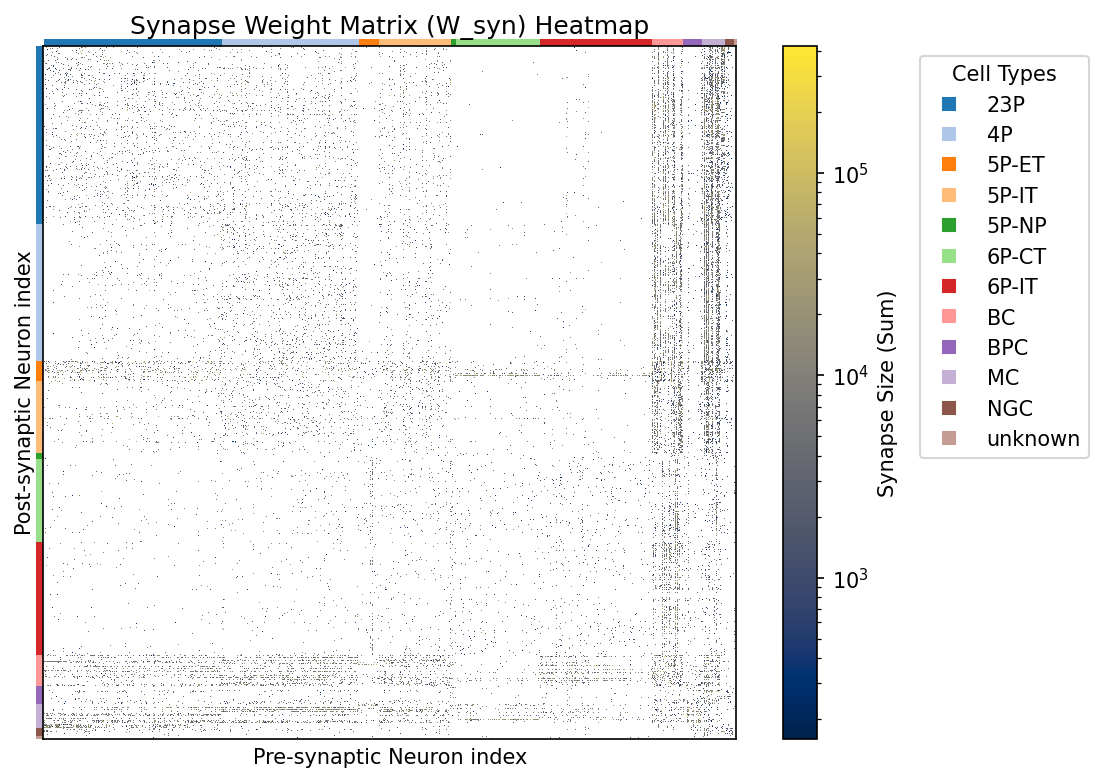

In [ ]:
import seaborn as sns
import matplotlib.colors as colors

# Prepare the data: convert to float numpy array to avoid type comparison errors
W_plot_data = W_syn_ct.to_numpy(dtype=float)
data_masked = np.ma.masked_where(W_plot_data <= 0, W_plot_data)

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Plot the heatmap
im = ax.imshow(
    data_masked,
    cmap="cividis",
    norm=colors.LogNorm(vmin=np.nanmin(data_masked), vmax=np.nanmax(data_masked)),
    aspect='equal',
    interpolation='nearest',
    rasterized=True
)

# Add the cell type color bars to the axes
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))

# Formatting
ax.set_title("Synapse Weight Matrix (W_syn) Heatmap")
ax.set_xlabel("Pre-synaptic Neuron index")
ax.set_ylabel("Post-synaptic Neuron index")
ax.set_xticks([])
ax.set_yticks([])

# Add Colorbar
cb = fig.colorbar(im, ax=ax, label='Synapse Size (Sum)')

# Add Legend
import matplotlib.lines as mlines
legend_elements = [mlines.Line2D([0], [0], color=plt.get_cmap("tab20")(i), label=ct, marker='s', linestyle='None')
                   for i, ct in enumerate(cts)]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.25, 1), title="Cell Types")

plt.show()

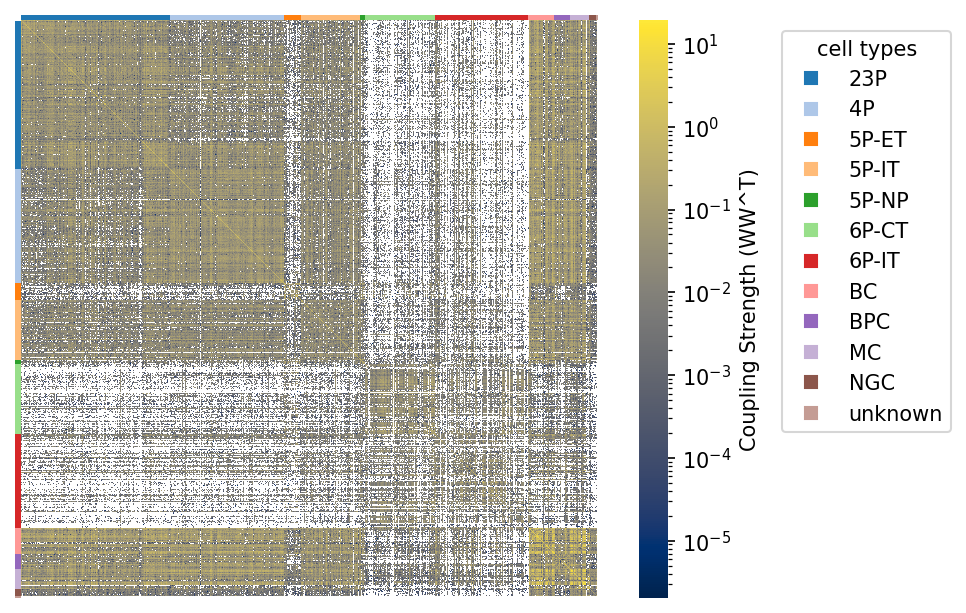

In [ ]:
import matplotlib.colors as colors

# Calculate Coupling
Coupling = (W_syn_ct.T @ W_syn_ct)
N = Coupling.shape[0]
Coupling = Coupling / np.trace(Coupling) * N

# Ensure data is numeric (float) to avoid comparison errors with strings
coupling_data = Coupling.to_numpy(dtype=float)
data_masked = np.ma.masked_where(coupling_data <= 0, coupling_data)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# Plot using imshow with LogNorm
im = ax.imshow(
    data_masked,
    cmap="cividis",
    norm=colors.LogNorm(vmin=np.nanmin(data_masked), vmax=np.nanmax(data_masked)),
    aspect='equal',
    interpolation='nearest',
    rasterized=True
)

# Styling
ax.set_facecolor('white')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

# Add Colorbar
cb = fig.colorbar(im, ax=ax, label='Coupling Strength (WW^T)')
cb.outline.set_linewidth(0)

# Adding row and column colors for cell types
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))

import matplotlib.lines as mlines
# add a legend for the cell types
legend_elements = [mlines.Line2D([0], [0], color=plt.get_cmap("tab20")(i), label=ct, marker='s', linestyle='None') for i, ct in enumerate(cts)]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.3, 1), title="cell types")

plt.show()

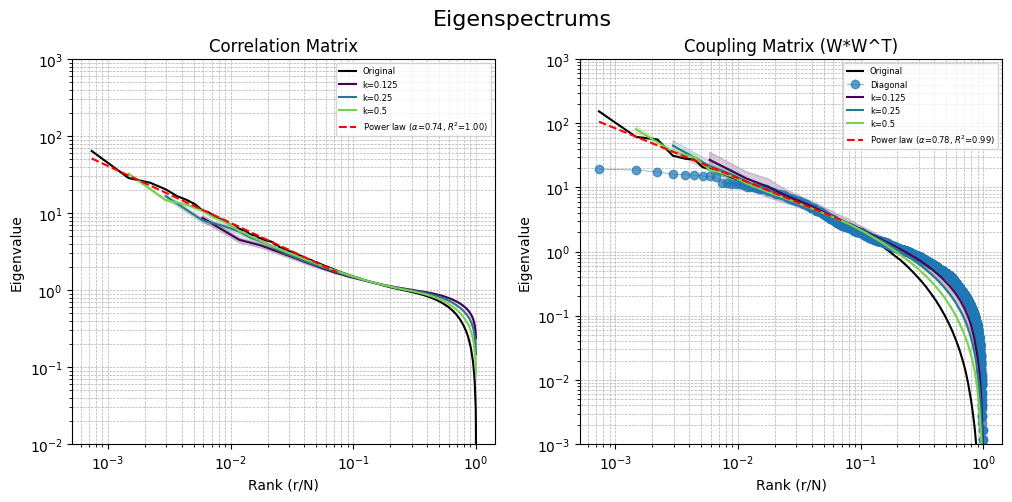

In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(src_path))
import subsampling

g = 0.7
CouplingMatrix = Coupling.to_numpy(dtype = 'float64')
W0 = subsampling.generate_W_matrix(CouplingMatrix,g,seed=43)
#W = J.to_numpy() / (120.0 * N)
Correlation_Matrix = subsampling.compute_functional_connectivity(W0)
d = np.sqrt(np.diag(Correlation_Matrix))

# 2. Normalize covariance to get correlation: C_ij / (std_i * std_j)
#np.outer(d, d) #creates the matrix of std_i * std_j
Correlation_Matrix = Correlation_Matrix / np.outer(d, d)

# 3. (Optional) Ensure diagonal is exactly 1.0 to fix floating point errors
#np.fill_diagonal(Correlation_Matrix, 1.0)


evals = np.linalg.eigvalsh(Correlation_Matrix)
evals = np.sort(evals)[::-1]

fit_corr = subsampling.fit_power_law_eigenvalues(evals,100)

k_fractions = [0.125, 0.25, 0.5]
n_iter = 50

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Eigenspectrums', fontsize=16)

ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax[0].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')
# ax[0].loglog(ranks_orig, np.sort(np.diag(Correlation_Matrix))[::-1],'o-', linewidth=1, alpha =0.5, label='Diagonal')

colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(Correlation_Matrix, k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax[0].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax[0].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)

ax[0].loglog(fit_corr['data_x'], fit_corr['fitted_y'], 'r--', linewidth=1.5,
              label=r'Power law ($\alpha$={:.2f}, $R^2$={:.2f})'.format(fit_corr['exponent'], fit_corr['r_squared']))


ax[0].set_xlabel('Rank (r/N)')
ax[0].set_ylabel('Eigenvalue')
ax[0].set_ylim([10**-2, 10**3])
ax[0].legend(fontsize=6)
ax[0].set_title('Correlation Matrix')
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)


evals = np.linalg.eigvalsh(CouplingMatrix)
evals = np.sort(evals)[::-1]

fit_coupling = subsampling.fit_power_law_eigenvalues(evals,100)


ranks_orig = (np.arange(len(evals)) + 1) / len(evals)
ax[1].loglog(ranks_orig, evals, 'k-', linewidth=1.5, alpha=1.0, label='Original')
ax[1].loglog(ranks_orig, np.sort(np.diag(CouplingMatrix))[::-1],'o-', linewidth=0.5, alpha =0.7, label='Diagonal')


colors = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))

for i, k_fraction in enumerate(k_fractions):
    mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(CouplingMatrix, k_fraction, n_iter)
    ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
    ax[1].loglog(ranks_sub, mean_evals, color=colors[i], linewidth=1.5, label='k={}'.format(k_fraction))
    ax[1].fill_between(ranks_sub, mean_evals - std_evals, mean_evals + std_evals, color=colors[i], alpha=0.2)

ax[1].loglog(fit_coupling['data_x'], fit_coupling['fitted_y'], 'r--', linewidth=1.5,
              label=r'Power law ($\alpha$={:.2f}, $R^2$={:.2f})'.format(fit_coupling['exponent'], fit_coupling['r_squared']))

ax[1].set_xlabel('Rank (r/N)')
ax[1].set_ylabel('Eigenvalue')
ax[1].set_ylim([10**-3, 10**3])
ax[1].legend(fontsize=6)
ax[1].set_title('Coupling Matrix (W*W^T)')
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

#fig.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

In [ ]:
import numpy as np

# Calculate Coupling again to ensure we have the latest state
Coupling_debug = (W_syn_ct.T @ W_syn_ct)

print(f"Coupling matrix shape: {Coupling_debug.shape}")
print(f"Number of non-zero elements in Coupling: {np.count_nonzero(Coupling_debug.values)}")
print(f"Coupling matrix max value: {Coupling_debug.values.max()}")
print(f"Coupling matrix min value: {Coupling_debug.values.min()}")
print(f"Contains NaNs: {Coupling_debug.isna().any().any()}")

# Check the masked data that goes into LogNorm
data_masked_debug = np.ma.masked_where(Coupling_debug <= 0, Coupling_debug)
print(f"\nMasked data (LogNorm input) info:")
print(f"Number of valid (unmasked) points: {data_masked_debug.count()}")
if data_masked_debug.count() > 0:
    print(f"Valid min: {np.nanmin(data_masked_debug)}")
    print(f"Valid max: {np.nanmax(data_masked_debug)}")
else:
    print("Warning: No valid points found for LogNorm (all values are <= 0 or NaN)")